# CS5016 Uncertainty in AI

#### Practical 1
##### Credits: 50% of the coursework and 30% of the module grade
##### Due date: 21:00 13/03/2026 (note that MMS is the definitive source for deadlines and weights.)

## Aims


The objectives of this assignment are:

* deepen your understanding of probabilistic generative models
* deepen your understanding of the EM algorithm
* gain experience in implementing generative AI models with latent variables

## Set-up

You are **only allowed** to use the following imported packages for this practical. 

In [108]:
# if you use jupyter-notebook, switch to %matplotlib notebook instead
%matplotlib inline
# %matplotlib notebook
%config Completer.use_jedi = False
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import logsumexp
from scipy.special import softmax
import numpy.linalg as linalg
# from sklearn.cluster import KMeans
from sklearn import metrics
# import scipy.sparse as sparse

In [109]:
# use fixed random number generator seed 
random_seed = 123
rng = np.random.default_rng(random_seed)

## Finite mixture models



In this question, we are going to implement an EM algorithm for a finite mixture of Bernoullis, which can be used to cluster binary-valued images and also generate or complete partial images. And, yes, it is called generative AI nowadays. 

The following write-up looks pretty long, but it only covers the necessary background. The algorithm is fairly simple and has been derived for you. And the implementation typically requires less than 10-15 lines of code. You may skip to the pseudo-code and implement the algorithm directly. But remember, a solid understanding of the underlying maths is essential when it comes to implementing ML algorithms. 




### Overview

We are going to use a modified MNIST handwritten digit dataset. The images are essentially $28 \times 28$ binary matricies, *i.e.* the pixels take values in $\{0, 1\}$. The spatial structure of the images is ignored, so each image/matrix is collapsed to a $784$-dimensional binary vector: $\mathbf{x} \in \{0,1\}^{784}$. 

The required dataset is imported below. In particular,
* `X_mnist_train`: a $4000 \times 784$ binary matrix, where each row is one image and there are 4000 images in the training data; 
* `Y_mnist_train`: the corresponding 4000 labels of the images
* `X_mnist_test`, `Y_mnist_test`: a further $1000 \times 784$ test data and labels 

In [110]:
## import MNIST dataset, it might take a while!
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', parser ='auto')

In [111]:
X_mnist = np.array(mnist.data) > 0.5 # binary-rise the data
Y_mnist = np.array(mnist.target, dtype ='int')
X_mnist_train = X_mnist[:4000, :] # use the first 4000 images as training data
Y_mnist_train = Y_mnist[:4000]
X_mnist_test = X_mnist[4000:5000, :] # the next 1000 as testing
Y_mnist_test = Y_mnist[4000:5000]

**Supervised learning:**
If the labels $\{z^{(i)}\}$ are known, the model parameters' estimates are simply the pooled sample means. That is: for $k=1,\ldots, K$

$$\boldsymbol{\mu}_k = \frac{1}{n_k} \sum_{i=1}^n \mathbb{1}(z^{(i)} =k)\mathbf{x}^{(i)}$$

* where $n_k = \sum_{i=1}^n \mathbb{1}(z^{(i)} =k)$ is the number of images belong to the $k$-th class.
* note that each $0\leq \mu_{kd} \leq 1$ indicates how bright a pixel at location $d$ should be (or how likely that pixel is a $1$) assuming it is digit $k$.

In [112]:
μs_sup = np.zeros((10, 784))
for k in range(10):
    μs_sup[k, :] = np.mean(X_mnist_train[Y_mnist_train == k, :] , axis=0)

And the learnt centers $\{\boldsymbol{\mu}_k\}$ are plotted below. They look pretty nice and clean.

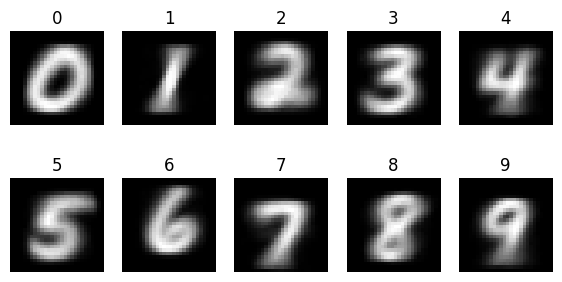

In [113]:
figure = plt.figure(figsize=(7, 3.5))
rows, cols= 2, 5
for k in range(10):
    img = μs_sup[k, :].reshape(28, 28)
    figure.add_subplot(rows, cols, k+1)
    plt.title(k)
    plt.axis("off")
    plt.imshow(img, cmap="gray")
plt.show();

Next, we are going to solve the problem **unsupervisedly**, *i.e.* do the clustering without knowing the labels $\{z^{(i)}\}$. To do it, we need a proper probabilistic generative model.

### Finite mixture of Bernoullis
_(You can skip this section if you are already familiar with the model)_

A finite mixture of Bernoullis (called `MixBern` hereafter) is very similar to other mixture models we have seen in the lecture. Compared with mixture of Gaussian, the only change is that we assume the component's likelihood is a collection of independent Bernoulli random variables. To be more specific, conditioned on the hidden cluster label $z^{(i)} =k$, each pixel, $x_d^{(i)} \in \{0, 1\}$, is an independent Bernoulli random variable (or coin tossing if you prefer) with a bias $\mu_{kd}$ ($0\leq \mu_{kd} \leq 1$): 

$$\begin{align} p(\mathbf{x}^{(i)}| z^{(i)}=k, \{\boldsymbol{\mu}_k\}_{k=1}^K) &= \prod_{d=1}^D p(x_d^{(i)} | z^{(i)}=k, \boldsymbol{\mu}_k) \\
&=\prod_{d=1}^D \mu_{kd}^{x^{(i)}_{d}} \cdot (1-\mu_{kd})^{1-x^{(i)}_d},
\end{align}$$

* where we have used the conditional independence assumption in the first equation then sub-in the Bernoulli's probability mass function in the second line. Make sure you understand the above formulas before moving on. 


The joint model factors as:

$$p(z^{(i)}, \mathbf{x}^{(i)}) = p(z^{(i)})p( \mathbf{x}^{(i)}|z^{(i)}),$$

* and the joint distribution encodes the following generative process: 

---
for $i=1,\ldots, n$
1. sample $z^{(i)}$ from a prior Categorical distribution with prior proportion parameter $\boldsymbol{\pi}$
$$z^{(i)} \sim \mathcal{Cat}(\boldsymbol{\pi})$$

2. For each pixel $d = 1,\ldots, D$,
    * conditioned on the sampled $z^{(i)}=k$, sample a Bernoulli variable with bias $\mu_{kd}$
$$x^{(i)}_d \sim \mathcal{Ber}(\mu_{kd})$$

----


The **observed or marginal likelihood**, due to the sum rule, is 

$$p(\mathbf{x}^{(i)}|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) = \sum_{k=1}^K p(z^{(i)}=k)p( \mathbf{x}^{(i)}|z^{(i)}=k) = \sum_{k=1}^K \pi_k \cdot p(\mathbf{x}^{(i)}| \boldsymbol{\mu}_k)$$

* EM aims to maximise the above w.r.t the model parameter $\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}$ via an iterative procedure

**Summary of notations**
It is a good idea to summarise the notations we have used so far

* ``n=4000``, the number of training images; the training data is indexed by $i$
* ``D = 784``, the number of pixels of each image vector $\mathbf{x}$, indexed by $d$
* ``K``, the number of mixture components, indexed by $k$

The model parameters we aim to learn are

$$\boldsymbol{\pi} = \begin{bmatrix}\pi_1, \pi_2, \ldots, \pi_K \end{bmatrix}^\top; \;\;\;\boldsymbol{\mu}s = \begin{bmatrix}\rule[.5ex]{2.5ex}{0.5pt}  & \boldsymbol{\mu}_1^\top & \rule[.5ex]{2.5ex}{0.5pt} \\
\rule[.5ex]{2.5ex}{0.5pt}  & \boldsymbol{\mu}_2^\top & \rule[.5ex]{2.5ex}{0.5pt} \\
&\vdots& \\
\rule[.5ex]{2.5ex}{0.5pt}  & \boldsymbol{\mu}_K^\top & \rule[.5ex]{2.5ex}{0.5pt} \\
\end{bmatrix}_{K\times D}$$

### Task 1.0 CDLL

Give an expression for the complete data log-likelihood function of the finite mixture model 

$$\text{CDLL}(\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})=\ln p(\{z^{(i)}, \mathbf{x}^{(i)}\}|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})$$

**Your answer here**:



For each data point $i$:

$$
p\big(z^{(i)}, x^{(i)} \mid \pi,\{\mu_k\}\big)
= p(z^{(i)} \mid \pi,\{\mu_k\}) p\big(x^{(i)} \mid z^{(i)}, \pi, \{\mu_k\}\big)  
= p(z^{(i)} \mid \pi) p\big(x^{(i)} \mid z^{(i)}, \{\mu_k\}\big)
$$

From lectures and above, we know that:

$$
p(z^{(i)} \mid \pi) = \pi_{k}
$$

$$
p\big(x^{(i)} \mid z^{(i)}, \{\mu_k\}\big)
=
\prod_{d=1}^{D}
\mu_{kd}^{\,x_d^{(i)}}
\left(1-\mu_{kd}\right)^{1-x_d^{(i)}}
$$

Looking at an individual observation, we get that:

$$
p\big(z^{(i)}, x^{(i)} \mid \pi,\{\mu_k\}\big) 
= \pi_{k} \prod_{d=1}^{D} \mu_{kd}^{\,x_d^{(i)}} \left(1-\mu_{kd}\right)^{1-x_d^{(i)}}
$$

Taking the log:
$$
\ln p\left(z^{(i)}, x^{(i)} \mid \pi, \{\mu_k\}\right) = 
\ln \pi_{k}
+
\sum_{d=1}^{D}
\Big(
x_d^{(i)} \ln \mu_{kd}
+
(1-x_d^{(i)}) \ln(1-\mu_{kd})
\Big)
$$

Now summing over the dataset:

$$
\ln p\left(\{z^{(i)}, x^{(i)}\}_{i=1}^n \mid \pi, \{\mu_k\}\right)
= \sum_{i=1}^n
\left[
\ln \pi_{k}
+
\sum_{d=1}^{D}
\Big(
x_d^{(i)} \ln \mu_{kd}
+
(1-x_d^{(i)}) \ln(1-\mu_{kd})
\Big)
\right]

$$

Now taking the logarithm form to get the CDLL:

$$
\mathrm{CDLL}(\pi,\{\mu_k\})
=
\sum_{i=1}^n
\left[
\ln \pi_{k}
+
\sum_{d=1}^{D}
\Big(
x_d^{(i)} \ln \mu_{kd}
+
(1-x_d^{(i)}) \ln(1-\mu_{kd})
\Big)
\right]
$$


We can also modify the CDLL to include the indicator function: $1[z^{(i)} = k]$. We know that $\prod_{k=1}^K x^{1[z^{(i)} = k]} = x$ and $\sum_{k=1}^K 1[z^{(i)} = k] = 1$, and thus we can get the following joint likelihood:
$$
p\big(z^{(i)}, x^{(i)} \mid \pi,\{\mu_k\}\big) 
= \prod_{k = 1}^{K}\Big[\pi_{k}^{1[z^{(i)}= k]} \prod_{d=1}^{D} (\mu_{kd}^{\,x_d^{(i)}} \left(1-\mu_{kd}\right)^{1-x_d^{(i)}})^{1[z^{(i)} = 1]}\Big]
= \prod_{k = 1}^{K}\Big[\pi_{k} \prod_{d=1}^{D} (\mu_{kd}^{\,x_d^{(i)}} \left(1-\mu_{kd}\right)^{1-x_d^{(i)}})\Big]^{1[z^{(i)} = k]}
$$

Taking the log:
$$
\ln p\left(z^{(i)}, x^{(i)} \mid \pi, \{\mu_k\}\right) 
= 
\sum_{k=1}^K 1[z^{(i)} = k] \Big[\ln \pi_{k}
+
\sum_{d=1}^{D}
\Big(
x_d^{(i)} \ln \mu_{kd}
+
(1-x_d^{(i)}) \ln(1-\mu_{kd})
\Big)
\Big]
$$

And therefore for summing over the complete data set we get:

$$
\mathrm{CDLL}(\pi,\{\mu_k\}) = \sum_{i=1}^n\sum_{k=1}^K 1[z^{(i)} = k] \Big[\ln \pi_{k}
+
\sum_{d=1}^{D}
\Big(
x_d^{(i)} \ln \mu_{kd}
+
(1-x_d^{(i)}) \ln(1-\mu_{kd})
\Big)
\Big]
$$

### Task 1.1 randomly sample from a `MixBern`

Firstly, write a method that randomly generates samples from a finite mixture of Bernoullis.  The method should have
**input** 
* `πs`: the prior mixture proportion $\pi_k$ for $k=1,\ldots, K$;
* `μs`: $K$ sets of bias parameters; or a $K\times D$ bias matrix (where $0 \leq\mu_{kd} \leq 1$)
* `n`: number of samples to generate

**output**
* `samples`: the gererated samples, should be a ``n`` by ``D`` matrix
* `zs`: the true cluster labels, where each $z_i \in 1, 2\ldots, K$ is the index of the cluster that has generated the ``i``-th sample.



In [114]:
def sample_mixberns(πs, μs, n):
    # Get the number of clusters and dimensions from the shape of μs
    K, D = μs.shape

    # Initialize an array to hold the sampled data points
    xs_samples = np.zeros((n, D), dtype=bool)

    # Sample cluster assignments for each data point according to the mixing coefficients
    zs = rng.choice(K, n, p=πs)
    
    # For each data point, sample its features based on the assigned cluster's Bernoulli parameters
    for i in range(n):
        k = zs[i]
        
        for d in range(D):
            prob = μs[k, d]
            
            if rng.random() < prob:
                xs_samples[i, d] = 1
            else:
                xs_samples[i, d] = 0

    return xs_samples, zs



Once you have done so, use the implemented method to sample `n=500` samples from a ($K=3$) MixBern with dimension size $D=9$, where the model parameters are
* $\boldsymbol{\pi} = [0.4, 0.3, 0.3]^\top$
* $\boldsymbol\mu_1 = [0.9, 0.9, 0.9, 0.1 \ldots, 0.1]^\top$; $\boldsymbol\mu_2 = [0.1, 0.1, 0.1, 0.9 , 0.9, 0.9, 0.1, 0.1, 0.1]^\top$ and $\boldsymbol\mu_3 = [0.1,  \ldots, 0.1, 0.9, 0.9, 0.9]^\top$; note that `μs` stacks the three vectors vertically to form a $3\times 9$ matrix


The simulated dataset will be very useful later on to debug your EM implementation. 

In [115]:
# to type π: type \pi + tab; \mu + tab for Θ 
trueπs = np.array([0.4, 0.3, 0.3])
trueμs = 0.1 * np.ones((3, 9))
trueμs[0, 0:3] = 0.9
trueμs[1, 3:6] = 0.9
trueμs[2, 6:] = 0.9
n_size = 500
sim_X, truezs = sample_mixberns(trueπs, trueμs, n_size)

In [116]:
trueμs;

### Task 1.2 E step implementation

The E step computes the $n\times K$ responsibility matrix $\mathbf{R}$, where each entry $r_{ik} = p( z^{(i)}=k|\mathbf{x}^{(i)})$ is the posterior probability of the $i$-th observation $\mathbf{x}^{(i)}$ belongs to the $k$-th cluster. Based on Bayes' rule, 

$$r_{ik} \propto \pi_k\cdot p(\mathbf{x}^{(i)}| z^{(i)}=k, \{\boldsymbol{\mu}_k\})$$

We usually work with probabilities in log space, and the formula becomes

$$\begin{align}
\ln r_{ik} &= \ln\pi_k + \ln p(\mathbf{x}^{(i)}| z^{(i)}=k, \{\boldsymbol{\mu}_k\}) + C\\
&=\ln\pi_k + \sum_{d=1}^D x_d^{(i)} \ln\mu_{kd} + (1-x_d^{(i)}) \ln(1-\mu_{kd}) + C
\end{align}$$

* make sure the above derivation makes sense to you

Now implement the above E-step
* `input`: the $n\times D$ data matrix $\mathbf{X}$, model parameter $\boldsymbol{\pi}$ and $\boldsymbol{\mu}s$

* `output`: the responsibility matrix and also the average marginal log likelihood: 

$$\ell(\boldsymbol{\pi}, \boldsymbol{\mu}s)=\frac{1}{n}\ln p(\{\mathbf{x}^{(i)}\}_{i=1}^n|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) = \frac{1}{n} \sum_{i=1}^n\ln\left \{ \sum_{k=1}^K \pi_k \cdot p(\mathbf{x}^{(i)}| \boldsymbol{\mu}_k)\right \}$$

In [117]:
def e_step(X, πs, μs):
    n, d = X.shape
    K = len(πs)

    # To avoid numerical issues, we remove the value 0, as log(0) is -infinty, and also remove the value 1, as log(1) is 0.
    eps = 1e-12
    μs = np.clip(μs, eps, 1 - eps)
    πs = np.clip(πs, eps, 1.0)

    # Initialize the responsibility matrix R and log-likelihood matrix LL.
    R = np.zeros((n, K))
    LL = np.zeros((n, K))

    # Looping through each observation
    for i in range(n):
        for k in range(K):
            # Use the posterior probability formula to calculate log responibility.
            LL[i,k] = np.log(πs[k]) + np.sum(X[i, :] * np.log(μs[k, :]) + (1 - X[i, :]) * np.log(1 - μs[k, :]))
       
    # We use the softmax here to convert the log-likelihood into probabilities, normalizing them across all logs for each data point.
    R = softmax(LL, axis=1) 
    
    loglik = 0.0
    for i in range(n):
        # Here, the log likelihood is calculated using the log-sum-exp trick to avoid numerical underflow issues.
        # LL(i, :) is the vector of log probabilities for all clusters for the i-th data point. That's why we use exponentiation
        m = np.max(LL[i, :])
        loglik += m + logsumexp(LL[i, :] - m)
        
    loglik /= n
    return R, loglik


### Task 1.3 the surrogate function 


The E step actually computes the expectation of the complete data log-likelihood function. Give an expression for the expected complete data log-likelihood function $\mathbb{E}[\ln p(\{z^{(i)}, \mathbf{x}^{(i)}\}|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})]$ in terms of $r_{ik}$ (which are computed with the current parameters.)


**Your answer here:**

From above, recall that:
$$
\ln p(\{z^{(i)}, \mathbf{x}^{(i)}\}|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
= \mathrm{CDLL}(\pi,\{\mu_k\}) 
= \sum_{i=1}^n\sum_{k=1}^K 1[z^{(i)} = k] \Big[\ln \pi_{k} + \sum_{d=1}^{D}\Big(x_d^{(i)} \ln \mu_{kd} + (1-x_d^{(i)}) \ln(1-\mu_{kd}) \Big) \Big]
$$

Taking the expecation of $\mathbb{E}[\ln p(\{z^{(i)}, \mathbf{x}^{(i)}\}|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})]$ we get:
$$
\mathbb{E}[\ln p(\{z^{(i)}, \mathbf{x}^{(i)}\}|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})] 
= \mathbb{E}\Big[\sum_{i=1}^n\sum_{k=1}^K 1[z^{(i)} = k] \Big[\ln \pi_{k} + \sum_{d=1}^{D}\Big(x_d^{(i)} \ln \mu_{kd} + (1-x_d^{(i)}) \ln(1-\mu_{kd}) \Big) \Big]\Big]
$$

As expectation is a linear operator, we can do the following:

$$
\mathbb{E}[\ln p(\{z^{(i)}, \mathbf{x}^{(i)}\}|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})] 
= \sum_{i=1}^n\sum_{k=1}^K \mathbb{E}\Big[1[z^{(i)} = k] \Big[\ln \pi_{k} + \sum_{d=1}^{D}\Big(x_d^{(i)} \ln \mu_{kd} + (1-x_d^{(i)}) \ln(1-\mu_{kd}) \Big) \Big] \Big]
= \sum_{i=1}^n\sum_{k=1}^K \mathbb{E}\Big[1[z^{(i)} = k]\Big] \Big[\ln \pi_{k} + \sum_{d=1}^{D}\Big(x_d^{(i)} \ln \mu_{kd} + (1-x_d^{(i)}) \ln(1-\mu_{kd}) \Big) \Big] 
$$

And since $\mathbb{E}[1[z^{(i)} = 1]] = r_{ik}$, we can simply substitute this into the equation to get the final form

$$
\mathbb{E}[\ln p(\{x^{(i)}, z^{(i)}\} | \theta)] = \sum_{i = 1}^n \sum_{k = 1}^K r_{ik} ( \ln\pi_{k} + \sum_{d=1}^D x_d^{(i)} \ln\mu_{kd} + (1-x_d^{(i)}) \ln(1-\mu_{kd}))
$$

### Task 1.4 M step implementation

The M step re-estimates the model parameter based on $\mathbf{R}$. Luckily, the re-estimation is exactly the same as EM for Gaussian mixture. In other words, the weighted MLE estimator for $\boldsymbol{\mu}_k$ are just the weighted sample average.

---
For $k=1, \ldots, K$:

$$\pi_k = \frac{n_k}{n};\;\; \boldsymbol{\mu}_k = \frac{\sum_{i=1}^n r_{ik} \cdot \mathbf{x}^{(i)}}{n_k},$$


* where $n_k = \sum_{i=1}^n r_{ik}$
---

Now implement the above M-step 
* `input`: the $n\times D$ data matrix and responsibility matrix

* `output`: the reestimated parameters $\boldsymbol{\pi}$ and $\boldsymbol{\mu}s$



In [118]:
def m_step(X, R):
    # Here n is the number of data points, d is the number of dimensions, K is the number of Bernoulli clusters
    n, d = X.shape
    _, K = R.shape

    # Initalise a vector of size K, representing the percentage of data points created by that cluster 
    πs = np.zeros(K)

    # Initialise a K x d matrix, where each entries (k, i) represents the probability that the ith data point is 1, given that it was created by the kth cluster
    μs = np.zeros((K, d))

    eps = 1e-12

    # Loop over all clusters
    for k in range(K):

        # Sum over all data points, the responsibility of the kth cluster for that data point
        n_k = np.sum(R[:, k])

        if n_k < 1e-8:
            print("Safeguard used")
            i = rng.integers(n)
            μs[k] = np.clip(X[i].astype(float), eps, 1 - eps)
            πs[k] = eps
            continue

        # Calculate the percentage of data points created by the kth cluster
        πs[k] = n_k / n

        # Initalise the sum to 0
        weighted_sum = np.zeros(d)
        for i in range(n):
            # Calculate the weighted sum of the data points, where the weight is the responsibility of the kth cluster for that data point
            weighted_sum += R[i, k] * X[i, :]
        
        # Get the weighted sample average
        μs[k, :] = weighted_sum / n_k

    μs = np.clip(μs, eps, 1 - eps)
    πs = np.clip(πs, eps, 1.0)
    πs = πs / np.sum(πs)  # renormalise, just in case

    return πs, μs

### Task 1.5 EM algorithm for MixBerns

Implement an EM algorithm that can learn the parameters of finite mixture of Bernoullis. A simple initialisation strategy is to randomly assign each observation to one of the $K$ cluster (initialise with a E step) then find the corresponding $\boldsymbol{\mu}s$. Feel free to try other initialisations. 

The method takes input 
* `X`: the input data
* `K`: the mixture component size
* `tol`: tolerance or stopping criterion
* `maxIters`: the maximum nunmber of iterations 

and it should output
* `logLiks`: the trajectory of the (log)-likelihood
* `πs, μs`: the learnt parameters of the finite mixture model
* `R` and `zs`: the responsibility matrix and the assigned clusters of the observations


In [151]:
def em_mixberns(X, K, tol = 1e-5, maxIters = 100):
	# n = number of data points, d = pixel number
	n, d = X.shape
	# set a uniform distribution for mean
	πs = np.ones(K) / K

	# Set up a random initialisation for μs, where each entry is between 0 and 1.
	#	μs = rng.random((K, d))

	# Set up each μs from real data points 
	idx = rng.choice(n, size=K, replace=False)
	μs = X[idx].astype(float)
	μs = np.clip(μs, 1e-12, 1 - 1e-12)

	# initialise the log-likelihood
	logLiks = []
	# create a responsibility matrix of size n x K
	R = np.zeros((n, K))
	# create a vector of size n, where each entry is the cluster assignment for that data point
	zs = np.zeros(n, dtype=int)

	for _ in range(maxIters):
		# E step
		R, loglik = e_step(X, πs, μs)
		logLiks.append(loglik)

		# M step
		πs, μs = m_step(X, R)

		# Check convergence
		if _ > 0 and abs(logLiks[_] - logLiks[_-1]) < tol:
			break

	# After convergence, we assign each data point to the cluster with the highest responsibility.
	zs = np.argmax(R, axis=1) 

	return logLiks, πs, μs, zs, R

#### Evaluate on the simulated dataset

Run your EM algorithm on the dataset simulated in Task 1.1. 
You may need to repeat the algorithm a few times with different random initialisations to avoid bad initialisations. You need to show:
* whether your algorithm can recover the true parameters when correct $K=3$ is given ? 
* plot the (log)Likelihood trajectory

Report your results below.

Final Log-likelihood: -4.896678605632143
Parameter estimation (Note that there can be some permutation in cluster labels) : 

Estimated mixing coefficients (πs): [0.393 0.304 0.304]
True mixing coefficients: [0.4 0.3 0.3]

Estimated means (μs): [[0.919 0.931 0.89  0.094 0.088 0.082 0.119 0.109 0.102]
 [0.107 0.136 0.099 0.473 0.476 0.431 0.539 0.512 0.54 ]
 [0.107 0.136 0.099 0.473 0.476 0.431 0.539 0.512 0.54 ]]
True means: [[0.9 0.9 0.9 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.9 0.9 0.9 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.9 0.9 0.9]]


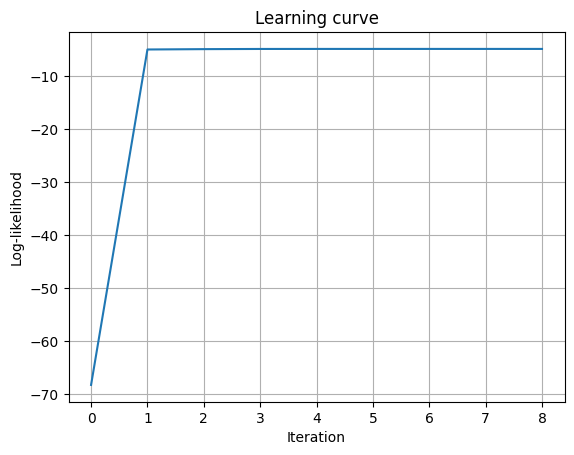

In [152]:
# Obtain the log-likelihood, estimated mixing coefficients, estimated means, cluster assignments, and responsibility matrix from the EM algorithm.
logLiks, πs, μs, zs, R = em_mixberns(sim_X, 3)

# Return the parameters
print("Final Log-likelihood:", logLiks[-1])

print("Parameter estimation (Note that there can be some permutation in cluster labels) : ")
print("")
print("Estimated mixing coefficients (πs):", np.round(πs, 3))
print("True mixing coefficients:", trueπs)
print("")
print("Estimated means (μs):", np.round(μs, 3))
print("True means:", trueμs)

# Plot the learning curve of log-likelihood over iterations.
plt.figure()
plt.plot(logLiks)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("Learning curve")
plt.grid(True)
plt.show()


#### Evaluate on MNIST
Run your EM algorithm on the MNIST dataset with $K=10$ and report the following

* plot the log likelihood trajectory

* report the adjusted rand index (you can use `metrics.adjusted_rand_score()`)

* plot the $K$ centers found by the EM algorithm (*i.e.* each row of $\boldsymbol{\mu}s$) as 28 by 28 pixeled images


Final avg marginal log-likelihood: -168.28061436359687
Estimated mixing coefficients (πs): [0.06  0.089 0.079 0.065 0.046 0.051 0.076 0.053 0.07  0.092 0.039 0.09
 0.058 0.07  0.064]
Adjusted Rand Index (ARI): 0.3433028638202451


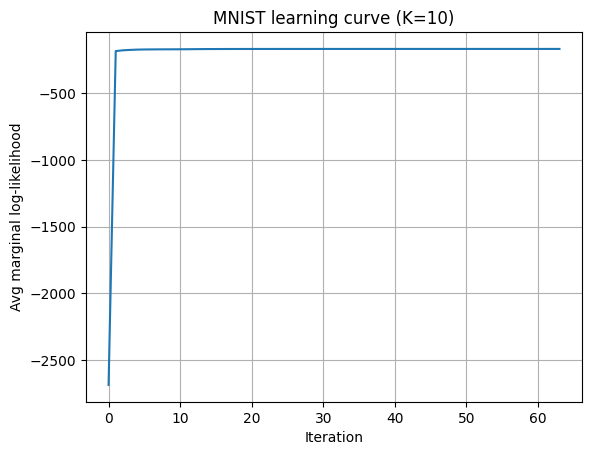

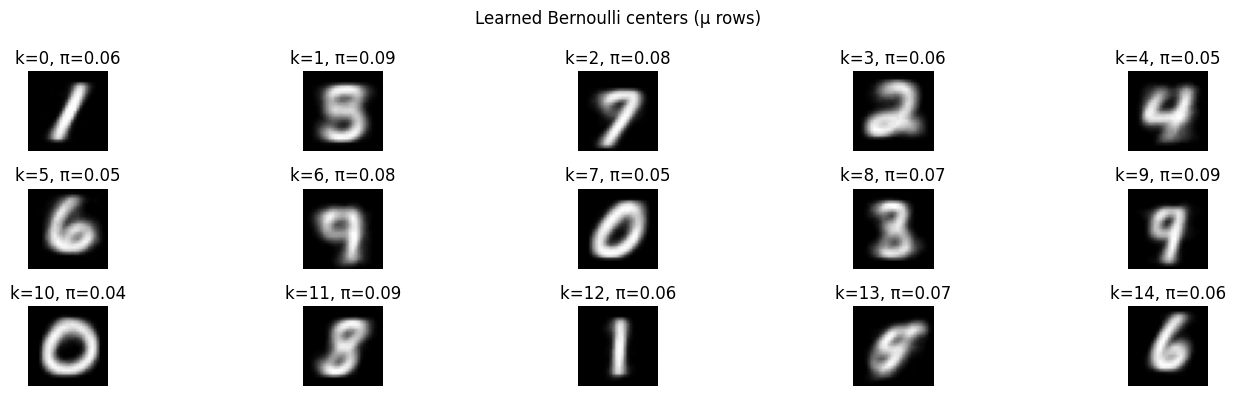

In [ ]:
# Run EM on MNIST (K = 10)
K = 10
logLiks, πs, μs, zs, R = em_mixberns(X_mnist_train, K)
print("Final avg marginal log-likelihood:", logLiks[-1])

print("Estimated mixing coefficients (πs):", np.round(πs, 3))

# Adjusted Rand Index (permutation-invariant)
ari = metrics.adjusted_rand_score(Y_mnist_train, zs)
print("Adjusted Rand Index (ARI):", ari)

# Plot log-likelihood trajectory
plt.figure()
plt.plot(logLiks)
plt.xlabel("Iteration")
plt.ylabel("Avg marginal log-likelihood")
plt.title("MNIST learning curve (K=10)")
plt.grid(True)
plt.show()

# Plot the K centers (rows of μs) as 28x28 images
#NOTE: if you change the number of K, you must change the number of subplots in the code below.
fig, axes = plt.subplots(2, 5, figsize=(K, 4))
axes = axes.ravel()

for k in range(K):
    axes[k].imshow(μs[k].reshape(28, 28), cmap="gray")
    axes[k].set_title(f"k={k}, π={πs[k]:.2f}")
    axes[k].axis("off")

plt.suptitle("Learned Bernoulli centers (μ rows)")
plt.tight_layout()
plt.show()


### Task 1.6 Image generation

Probabilistic generative models such as MixBerns can be used to generate new images.  It is because the model comprises distributions for both the hidden label $z$ and also the feature data $\mathbf{x}$. 

Now consider the following problem. You are given partially observed images (*e.g.* images on the left-hand side) and want to complete the images. The original images are listed in the middle column. The completed images (on the right-hand side) are generated by a learnt MixBern model (with $K=15$). Although MixBern's model is very basic and not "deep" in any sense, it does a decent job at generating hand-written images at least. 

![p1](https://sites.cs.st-andrews.ac.uk/people/lf28/CS5014/P2/mnist_cover.png)
![p2](https://sites.cs.st-andrews.ac.uk/people/lf28/CS5014/P2/mnist_origin.png)
![p3](https://sites.cs.st-andrews.ac.uk/people/lf28/CS5014/P2/mnist_impute.png)




![p1](https://sites.cs.st-andrews.ac.uk/people/lf28/CS5014/P2/mnist_cover2.png)
![p2](https://sites.cs.st-andrews.ac.uk/people/lf28/CS5014/P2/mnist_origin.png)
![p3](https://sites.cs.st-andrews.ac.uk/people/lf28/CS5014/P2/mnist_impute2.png)

#### Posterior predictive distribution
The benefit of adopting a formal probabilistic approach is that all ML problems uniformly translate to formal probabilistic inferences. And the results emerge naturally.

To be more specific, one only needs to implement a posterior predictive distribution for the missing data. Denote the observed pixel index set as $\mathcal{O}$, and the missing/hidden pixel index set as $\mathcal{H}$. Note that $\mathcal{O} \cup\mathcal{H} = \{1,2,\ldots, 784\}$. The posterior predictive distribution is defined as 


$$p(\mathbf{x}_{\mathcal{H}}=\mathbf{1}|\mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) = \sum_{k=1}^K p(\mathbf{x}_{\mathcal{H}}=\mathbf{1} |z=k,  \boldsymbol{\mu}_k) p(z =k|\mathbf{x}_{\mathcal{O}})$$

* where $\mathbf{x}_\mathcal{O}$ denotes the observed sub-vector and $\mathbf{x}_\mathcal{H}$ is the missing/hidden part

* the above distribution is a weighted average of $K$ predictions and each predictions are simply

$$p(\mathbf{x}_{\mathcal{H}} =\mathbf{1} |z=k,  \boldsymbol{\mu}_k) = \boldsymbol{\mu}_{k,\mathcal{H}}$$
 
* and we can show the posterior is almost the same as before, but simply ignore the missing pixels

$$p(z =k|\mathbf{x}_{\mathcal{O}}) \propto \pi_k \prod_{d \in \mathcal{O}} p(x_d|z=k, \boldsymbol{\mu}_k)$$

#### Task 1.6.1 Conceptual question
* show that the above posterior predictive distributions are correct based on the generative model and probability rules.


1. 
Using the law of total probability over $z$:
$$
p(\mathbf{x}_{\mathcal{H}}=\mathbf{1}|\mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) = \sum_{k=1}^K p(\mathbf{x}_{\mathcal{H}}=\mathbf{1}, z^{(i)} = k|\mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
$$
Then, using the conditional probability formula on each term inside the sum:
$$
p(\mathbf{x}_{\mathcal{H}}=\mathbf{1}|\mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) 
= \sum_{k=1}^K p(\mathbf{x}_{\mathcal{H}}=\mathbf{1} | z^{(i)} = k, \mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) p(z^{(i)} = k | \mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
$$
Which simplies down to:
$$
p(\mathbf{x}_{\mathcal{H}}=\mathbf{1}|\mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) = \sum_{k=1}^K p(\mathbf{x}_{\mathcal{H}}=\mathbf{1} |z=k,  \boldsymbol{\mu}_k) p(z =k|\mathbf{x}_{\mathcal{O}})
$$

2. 



Note that since $\mathbf{x}_{\mathcal{H}}$ is a vector, we can simply go through the product of each of its individual entries, as they are all conditionally independent, and get:

$$
p(\mathbf{x}_{\mathcal{H}} =\mathbf{1} |z=k,  \boldsymbol{\mu}_k) = \prod_{h \in \mathcal{H}}p(x_h =\mathbf{1} |z=k,  \boldsymbol{\mu}_k)
$$

Since we know from the Bernoulli model that $p(x_h = 1 | z = k, \boldsymbol{\mu}_k) = \boldsymbol{\mu}_{kh}$, we can substitute this into our equation to get:
$$
p(\mathbf{x}_{\mathcal{H}} =\mathbf{1} |z=k,  \boldsymbol{\mu}_k) = \prod_{h \in \mathcal{H}} \boldsymbol{\mu}_{kh}
$$

Which gives us:
$$
p(\mathbf{x}_{\mathcal{H}} =\mathbf{1} |z=k,  \boldsymbol{\mu}_k) = \boldsymbol{\mu}_{k,\mathcal{H}}
$$

3. 
We can apply to conditional probability formula to $p(z =k|\mathbf{x}_{\mathcal{O}}, \mathbf{π}, \{ \mathbf{\mu_{k}} \})$ to get:

$$
p(z =k|\mathbf{x}_{\mathcal{O}}, \mathbf{π}, \{ \mathbf{\mu_{k}} \})  = \frac{p(z = k, \mathbf{x}_{\mathcal{O}} | \mathbf{π}, \{ \mathbf{\mu_{k}} \})}{p(\mathbf{x}_{\mathcal{O}} | \mathbf{π}, \{ \mathbf{\mu_{k}} \})}
$$

Then, using the conditional probability formula again on $p(z = k, \mathbf{x}_{\mathcal{O}} | \mathbf{π}, \{ \mathbf{\mu_{k}} \})$, we get:
$$
p(z =k|\mathbf{x}_{\mathcal{O}}, \mathbf{π}, \{ \mathbf{\mu_{k}} \})  = \frac{p(\mathbf{x}_{\mathcal{O}}| z = k, \mathbf{π}, \{ \mathbf{\mu_{k}} \}) p(z = k | \mathbf{π}, \{ \mathbf{\mu_{k}} \})}{p(\mathbf{x}_{\mathcal{O}} | \mathbf{π}, \{ \mathbf{\mu_{k}} \})}
$$

Which simplifies down to:
$$
p(z =k|\mathbf{x}_{\mathcal{O}}, \mathbf{π}, \{ \mathbf{\mu_{k}} \})  = \frac{p(\mathbf{x}_{\mathcal{O}}| z = k, \{ \mathbf{\mu_{k}} \}) \pi_k}{p(\mathbf{x}_{\mathcal{O}} | \mathbf{π}, \{ \mathbf{\mu_{k}} \})}
$$

Since $\mathbf{x}_{\mathcal{O}}$ is a vector, we can look at it's individual entries to get $p(\mathbf{x}_{\mathcal{O}}| z = k, \{ \mathbf{\mu_{k}} \}) = \prod_{d \in \mathcal{O}}p(x_d | z = k , \{ \mathbf{\mu_{k}} \})$. Substituting this into our equation gives us:
$$
p(z =k|\mathbf{x}_{\mathcal{O}}, \mathbf{π}, \{ \mathbf{\mu_{k}} \}) = \frac{\pi_k \prod_{d \in \mathcal{O}} p(x_d | z = k,  \{ \mathbf{\mu_{k}} \})}{p(\mathbf{x}_{\mathcal{O}} | \mathbf{π}, \{ \mathbf{\mu_{k}} \})}
$$

Finally, note that our denominator does not depend on $k$, thus we can write

$$
p(z =k|\mathbf{x}_{\mathcal{O}}) \propto \pi_k \prod_{d \in \mathcal{O}} p(x_d|z=k, \boldsymbol{\mu}_k)
$$

#### Task 1.6.2 Implementation 

* Replicate the above result by implementing `posterior_predictive_impute(...)`
  * `input`: a vector with missing data and learnt model parameter $\boldsymbol{\pi}$ and $\boldsymbol{\mu}s$
  * `output`: an imputed vector where the missing parts are inputed with the posterior mean


Hint: just change the `E-step` first (to incorporate the missing data, ignore the missing pixels) then compute a weighted average)

In [ ]:
## generate images with missing pixels for the top half
X_mnist_cover1 = np.empty_like(X_mnist_test, dtype='f')
X_mnist_cover1[:] = X_mnist_test
# setting the top half pixels to nan/missing
X_mnist_cover1[:, 0: int(784//2)] = np.nan


# generate images with diagonal missing pixels
X_mnist_cover2 = np.empty_like(X_mnist_test, dtype='f')
X_mnist_cover2[:] = X_mnist_test
# setting the upper-triangular pixels to nan/missing
for i in range(X_mnist_cover2.shape[0]):
    img = X_mnist_cover2[i].reshape(28, 28)
    mask = np.triu(np.ones((28, 28), dtype=bool), k=0)  # upper-triangular mask
    img[mask] = np.nan
    X_mnist_cover2[i] = img.reshape(-1)

# generate images with random 50% missing black pixels
X_mnist_cover3 = np.empty_like(X_mnist_test, dtype='f')
X_mnist_cover3[:] = X_mnist_test
# setting random 50% pixels to nan/missing for each image
for i in range(X_mnist_cover3.shape[0]):
    missing_idx = rng.choice(784, size=784 // 2, replace=False)
    X_mnist_cover3[i, missing_idx] = np.nan

In [ ]:
def posterior_predictive_impute(x, πs, μs):

	# find the missing idx/observed idx set of x
    missing_idx = np.isnan(x)
    observed_idx = ~missing_idx
	
    # compute r = p(z|x); you need to modify the E step a bit!
	# Set the number of clusters K, to the length of πs
    K = len(πs)
	
    # Initialise a vector of the size of cluster, to indicate, for each cluster k, the log probability of that cluster being responsible for the data point x, given the observed pixels.
    log_prob = np.zeros(K)

	# Loop through each cluster k
    for k in range(K):
        mu_k = μs[k]
        log_prob[k] = np.log(πs[k]) + np.sum(x[observed_idx] * np.log(mu_k[observed_idx]) +(1 - x[observed_idx]) * np.log(1 - mu_k[observed_idx]))
	
	# Use the max-trick to avoid numerical issues
    log_prob -= np.max(log_prob)
    r = np.exp(log_prob)
    r /= np.sum(r)

	# instead of looping, we can simply do matrix multiplication
    x_pred = r @ μs
	# lastly add back the observed pixels xo to the predictive mean
    x_pred[observed_idx] = x[observed_idx]

    return x_pred

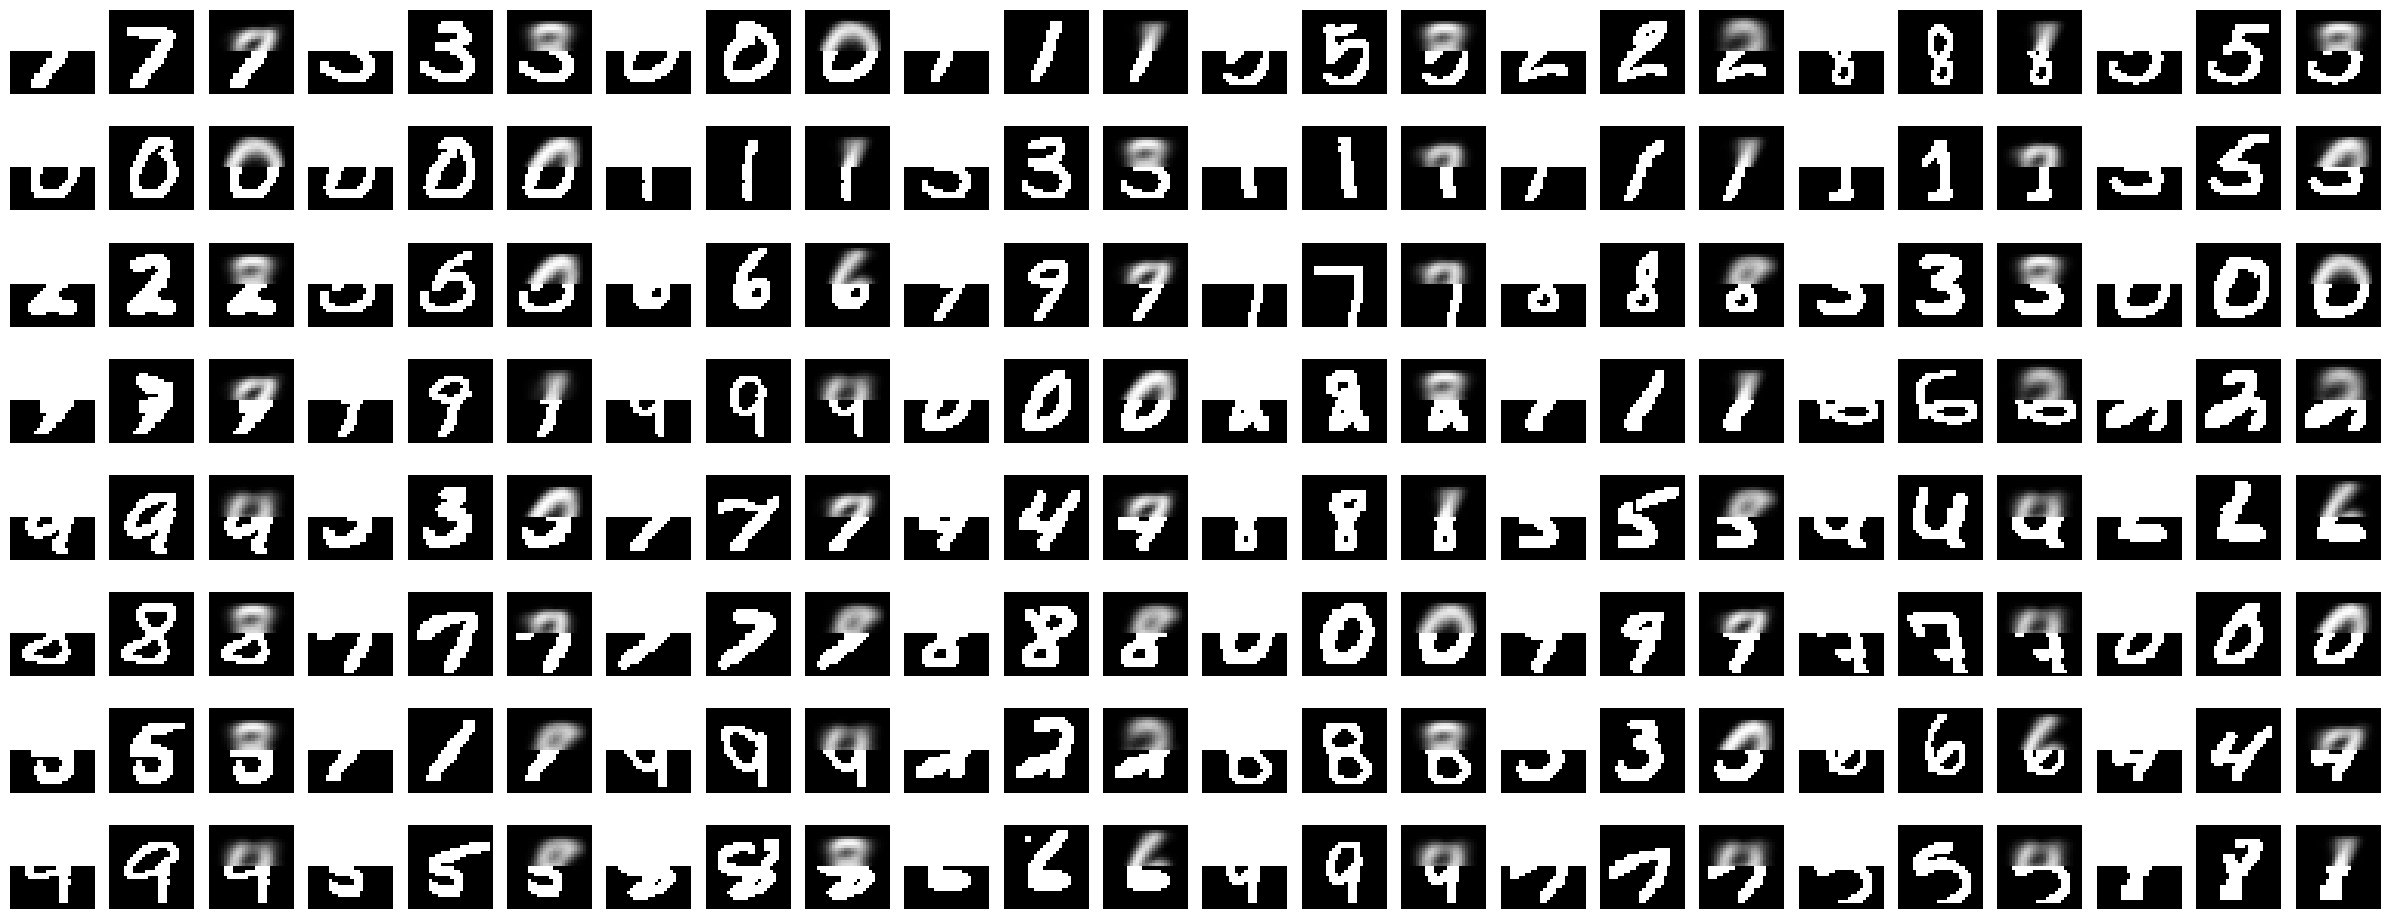

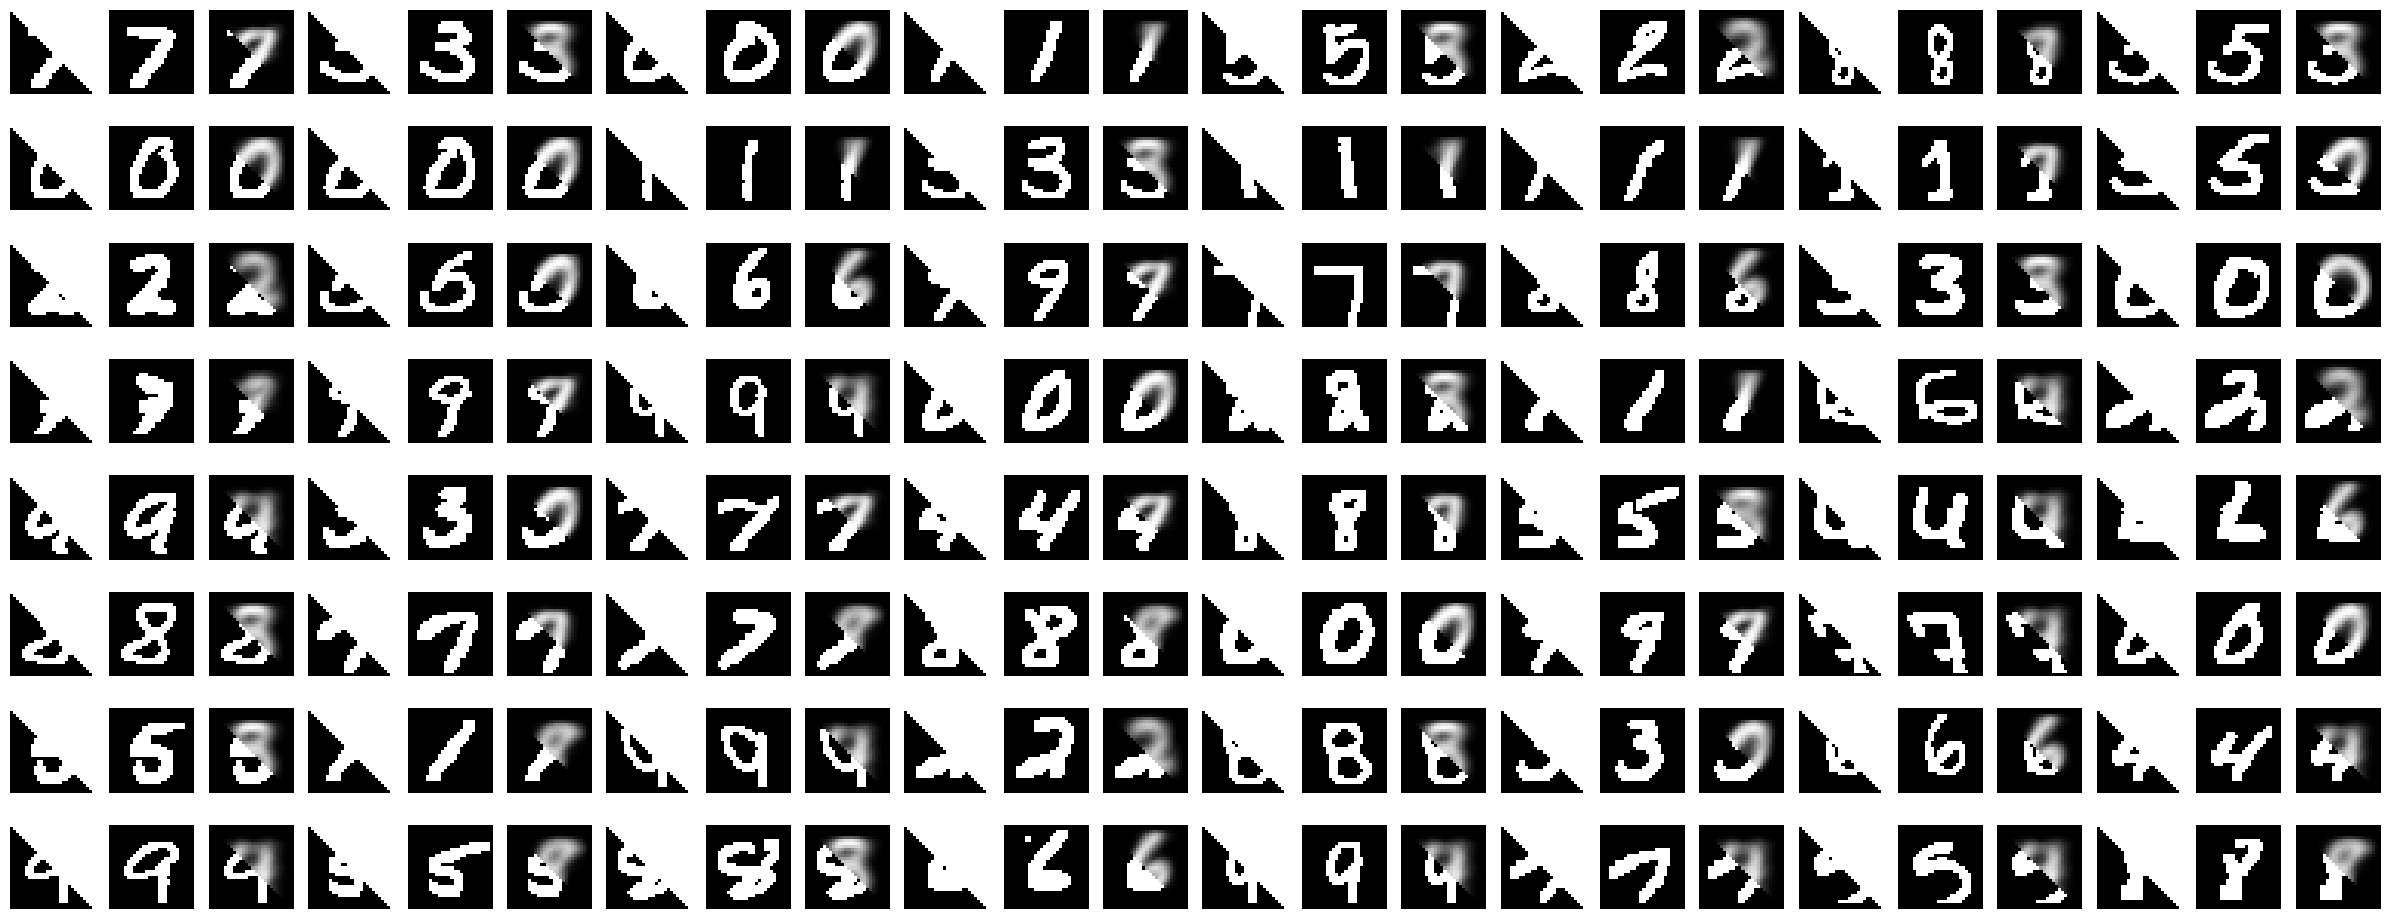

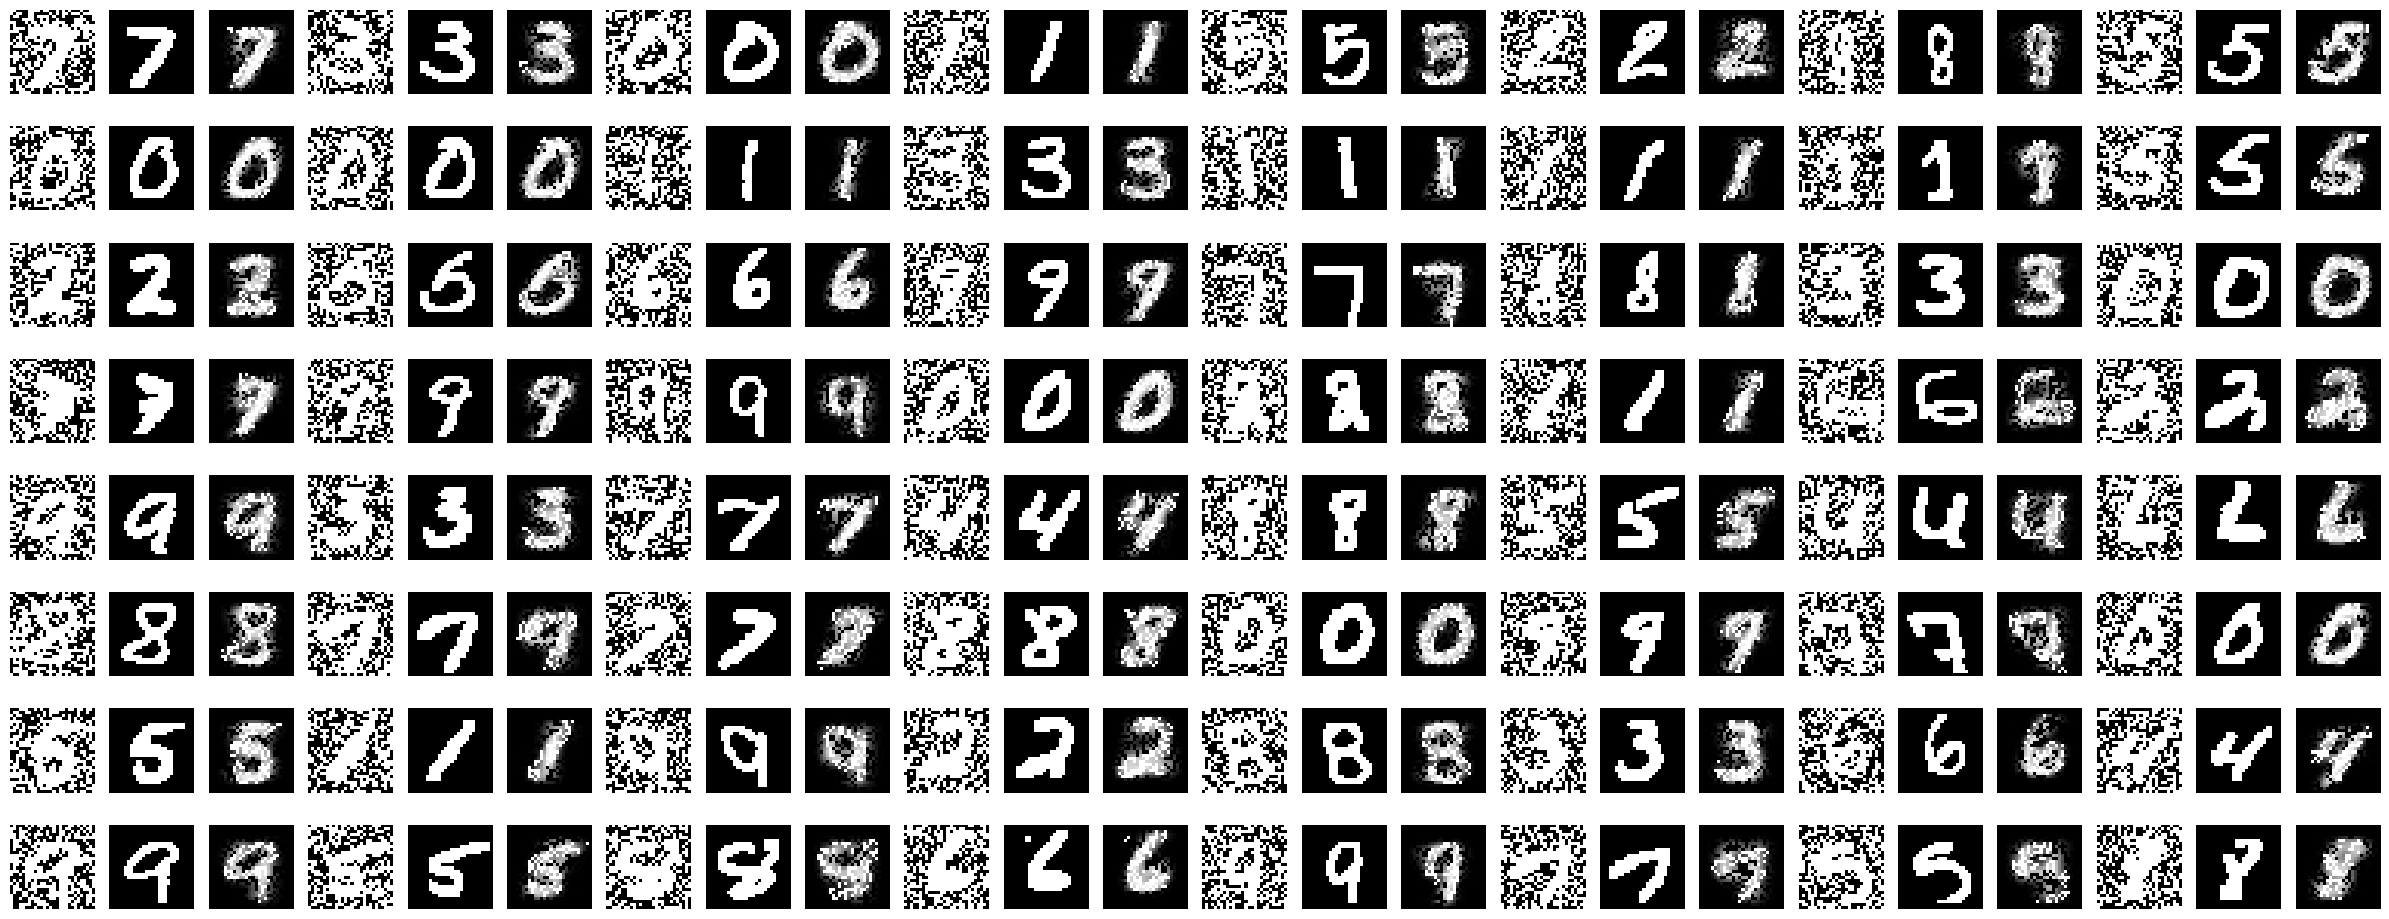

In [ ]:
# Impute the top-half-masked test images
X_mnist_imp1 = np.array([
    posterior_predictive_impute(x, πs, μs)
    for x in X_mnist_cover1
])

# Impute the diagonal-masked test images
X_mnist_imp2 = np.array([
    posterior_predictive_impute(x, πs, μs)
    for x in X_mnist_cover2
])

# Impute the random-50%-masked test images
X_mnist_imp3 = np.array([
    posterior_predictive_impute(x, πs, μs)
    for x in X_mnist_cover3
])

# Plot the different imputations
def plot_imputations(X_masked, X_original, X_imputed, nrows=8, ncols=8):
    fig, axes = plt.subplots(nrows, ncols * 3, figsize=(ncols * 3, nrows * 1.2))
    
    for i in range(nrows * ncols):
        r = i // ncols
        c = i % ncols

        # masked image
        ax = axes[r, 3 * c]
        ax.imshow(X_masked[i].reshape(28, 28), cmap="gray")
        ax.axis("off")

        # original image
        ax = axes[r, 3 * c + 1]
        ax.imshow(X_original[i].reshape(28, 28), cmap="gray")
        ax.axis("off")

        # imputed image
        ax = axes[r, 3 * c + 2]
        ax.imshow(X_imputed[i].reshape(28, 28), cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_imputations(X_mnist_cover1, X_mnist_test, X_mnist_imp1, nrows=8, ncols=8)
plot_imputations(X_mnist_cover2, X_mnist_test, X_mnist_imp2, nrows=8, ncols=8)
plot_imputations(X_mnist_cover3, X_mnist_test, X_mnist_imp3, nrows=8, ncols=8)

### Task 1.7 Learning by gradient descent (Extension)


An alternative approach to learn the parameters for the mixture model is to directly optimise the log-likelihood function. 

$$\boldsymbol{\pi}_{MLE}, \boldsymbol{\mu}_{MLE} \leftarrow \arg\max_{\boldsymbol{\pi}, \boldsymbol{\mu}} \ell(\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})$$

where the log likelihood function is
$$\ell(\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})=\frac{1}{n}\ln p(\{\mathbf{x}^{(i)}\}_{i=1}^n|\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) = \frac{1}{n} \sum_{i=1}^n\ln\left \{ \sum_{k=1}^K \pi_k \cdot p(\mathbf{x}^{(i)}| \boldsymbol{\mu}_k)\right \}$$


Apply gradient descent to find the MLE estimator. You may use auto-diff packages such as `Autograd` (or `Jax`) for this task. 

Hint: you need to reparameterise your parameters such that they are un-constrained

We want to find 
$$ 
\boldsymbol{\pi}_{MLE}, \boldsymbol{\mu}_{MLE} \leftarrow \arg\max_{\boldsymbol{\pi}, \boldsymbol{\mu}} \ell(\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) 
$$ 

which is the same as writing 
$$
\boldsymbol{\pi}_{MLE}, \boldsymbol{\mu}_{MLE} \leftarrow \arg\max_{\boldsymbol{\pi}, \boldsymbol{\mu}}  \frac{1}{n} \sum_{i=1}^n\ln \Big \{ \sum_{k=1}^K \pi_k \cdot p(\mathbf{x}^{(i)}| \boldsymbol{\mu}_k) \Big \} = \arg\max_{\boldsymbol{\pi}, \boldsymbol{\mu}}  \frac{1}{n} \sum_{i=1}^n\ln \Big \{ \sum_{k=1}^K \pi_k \cdot \prod_{d=1}^{D}\mu_{kd}^{\,x_d^{(i)}} \left(1-\mu_{kd}\right)^{1-x_d^{(i)}} \Big \}
$$

However, both $\boldsymbol{\pi}_k, \boldsymbol{\mu}_{kd} $ are constraint, with 
$\boldsymbol{\pi}_k ≥ 0 \text{ and } \sum_{k} \boldsymbol{\pi}_k = 1 $, and $ 0 < \boldsymbol{\mu}_{kd} < 1 $.

We can introduce unconstrained variables to deal with this: $ a \in \R^k$ for the mixture weights and $ b_{kd} \in \R$ for the Bernoulli parameters, where: 
$$
\boldsymbol{\pi}_k = \frac{e^{a_k}}{\sum_{j=1}^K e^{a_j}}
$$

and 

$$
\boldsymbol{\mu}_{kd} = \sigma(b_{kd}) = \frac{1}{1 + e^{-b_{kd}}}
$$

This allows to perform unconstrained gradient descent on the two parameters, and optimise over $a$ and $b$.

In [ ]:
import autograd.numpy as anp
from autograd import grad

# Can import special logsumexp which is compatible with autograd's numpy
from autograd.scipy.special import logsumexp

# Define sigmoid function using autograd's numpy
def sigmoid(x):
    return 1.0 / (1.0 + anp.exp(-x))

# Define softmax function using autograd's numpy
def softmax_autograd(a):
    a = a - anp.max(a)
    ea = anp.exp(a)
    return ea / anp.sum(ea)

# Initialize the parameters for gradient descent optimization. Note that the gradient optimisation is extremely sensitive to the initialisation.
def init_gd_params(K, D, rng, X):
    # a is a vector of size K, representing the unnormalised log probabilities of the clusters (before softmax)
    a = np.zeros(K)

    # we want to set b such that sigmoid(b) is close to the data points, so we can start with a good initialisation. We can randomly select K data points as the initial means for the Bernoulli distributions.
    idx = rng.choice(X.shape[0], size=K, replace=False)
    X0 = X[idx]

    # Soft digit-like initialization for b
    # If X is binary {0,1}, then:
    # X=0 -> b≈-2, sigmoid(b)≈0.12
    # X=1 -> b≈+2, sigmoid(b)≈0.88
    b = 2.0 * (2.0 * X0 - 1.0)

    # add a bit of noise so components don't stay too symmetric
    b = b + rng.normal(0.0, 0.1, size=(K, D))

    return a, b


# Define the average log-likelihood function for gradient descent optimization
def avg_log_likelihood(params, X):

    # Unpack the parameters into a (representation of πs) and b (representation of μs)
    a, b = params

    # Number of observations is n, and number of features is D
    n, D = X.shape

    # Calculate the mixing coefficients (πs) and the means (mus) using the softmax and sigmoid functions, respectively.
    pis = softmax_autograd(a)
    mus = sigmoid(b)

    # Do the same clipping mechanism as before to avoid numerical issues with log(1)
    eps = 1e-12
    pis = anp.clip(pis, eps, 1.0)
    mus = anp.clip(mus, eps, 1.0 - eps)

    # Compute the log-likelihood
    log_joint = anp.log(pis)[None, :] + anp.sum( X[:, None, :] * anp.log(mus[None, :, :]) + (1.0 - X[:, None, :]) * anp.log(1.0 - mus[None, :, :]), axis=2)
    
    # Find log likelihood of each point
    log_marginal = logsumexp(log_joint, axis=1)

    # Return the average log-likelihood across all data points
    return anp.mean(log_marginal)

# Define the negative log-likelihood
def neg_avg_log_likelihood(params, X):
    return -avg_log_likelihood(params, X)

# Compute the gradient of the negative average log-likelihood with respect to the parameters
grad_fn = grad(neg_avg_log_likelihood)

# Perform gradient descent 
def fit_mixbern_graddescent(X, K, num_steps=500, lr_a=0.001, lr_b = 0.005):
    # Number of observations is n, and number of features is D
    n, D = X.shape

    # Initaliase the parameters from function
    a, b = init_gd_params(K, D, rng, X)

    # Pack the parameters into a tuple for gradient computation
    params = (a, b)

    # Create a losses list
    losses = []
    
    # Perform gradient descent
    for step in range(num_steps):

        # Print the step number every 100 steps to track progress as the function is quite long
        if step % 100 == 0:
            print(f"Step {step}/{num_steps}")
        
        # Compute the gradient of the negative average log-likelihood with respect to the parameters
        g_a, g_b = grad_fn(params, X)

        # update the parameters using the computed gradients and the learning rates
        a = a - lr_a * g_a
        b = b - lr_b * g_b
        params = (a, b)

        # add the losses to list to track the learning curve
        losses.append(neg_avg_log_likelihood(params, X))

    # After optimization, compute the final πs and mus using the softmax and sigmoid functions
    pis = softmax_autograd(a)
    mus = sigmoid(b)

    return pis, mus, losses

Step 0/1000
Step 100/1000
Step 200/1000
Step 300/1000
Step 400/1000
Step 500/1000
Step 600/1000
Step 700/1000
Step 800/1000
Step 900/1000
Final avg marginal log-likelihood: -298.41275006047624
Estimated mixing coefficients (πs_gd): [0.098 0.099 0.1   0.097 0.107 0.096 0.105 0.102 0.093 0.103]


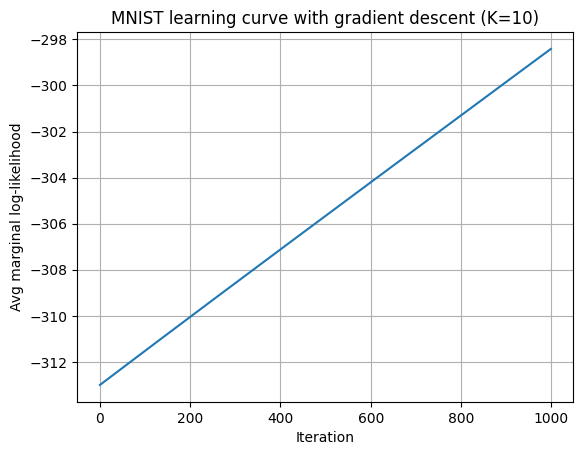

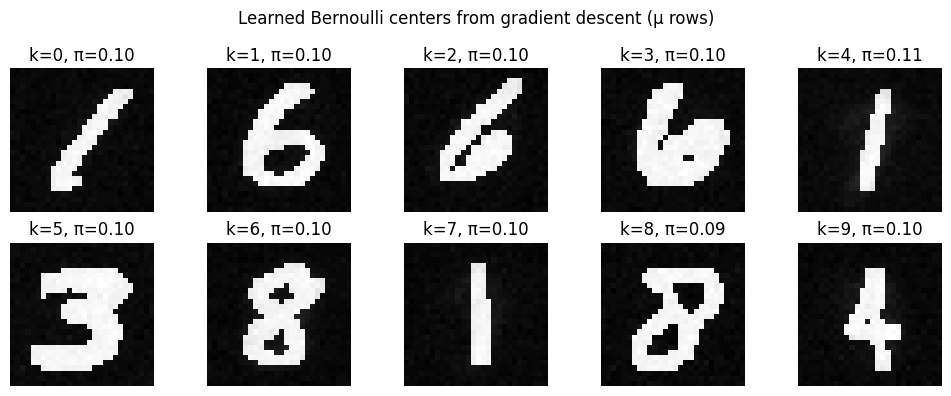

In [ ]:
# Example usage
K = 10

#Takes around 50 seconds per 100 steps. 
πs_graddescent, μs_graddescent, losses = fit_mixbern_graddescent(X_mnist_train, K, num_steps=1000)

print("Final avg marginal log-likelihood:", -losses[-1])
print("Estimated mixing coefficients (πs_gd):", np.round(np.array(πs_graddescent), 3))

# 1) Plot log-likelihood trajectory
plt.figure()
plt.plot(-np.array(losses))  # negative because losses_gd stores negative log-likelihood
plt.xlabel("Iteration")
plt.ylabel("Avg marginal log-likelihood")
plt.title("MNIST learning curve with gradient descent (K=10)")
plt.grid(True)
plt.show()

# 2) Plot the K centers (rows of mus_gd) as 28x28 images
fig, axes = plt.subplots(2, 5, figsize=(K, 4))
axes = axes.ravel()

for k in range(K):
    axes[k].imshow(np.array(μs_graddescent[k]).reshape(28, 28), cmap="gray")
    axes[k].set_title(f"k={k}, π={πs_graddescent[k]:.2f}")
    axes[k].axis("off")

plt.suptitle("Learned Bernoulli centers from gradient descent (μ rows)")
plt.tight_layout()
plt.show()

## Submission
Hand in via MMS: the completed jupyter notebook. Your notebook should be reproducible. 



## Marking

For the conceptual questions, you should type the maths expression in LaTeX in the given markdown cell. Screenshots of handwritten answers are strongly discouraged. Check this beginner guide to LaTeX if needed: https://www.cs.princeton.edu/courses/archive/fall05/cos433/Latex/latex-guide.pdf

Your submission will be marked as a whole. 

* to get a grade up to 13, you are expected to complete Task 1.0 to Task 1.5 to a reasonable standard 
* to get a grade above 13 and up to 15, you are expected to complete all tasks except 1.6 to an excellent standard
* to achieve a grade of 16-18, you are expected to finish all tasks except Task 1.6 flawlessly 
* to get a mark above 18, you are expected to make an excellent attempt on the extension


Marking is according to the standard mark descriptors published in the Student Handbook at:

https://info.cs.st-andrews.ac.uk/student-handbook/learning-teaching/feedback.html#GeneralMarkDescriptors

The standard penalty for late submission applies (Scheme A: 1 mark per 24 hour period, or part thereof). Check the student handbook for further details: https://info.cs.st-andrews.ac.uk/student-handbook/learning-teaching/assessment.html

You must reference any external sources used. Guidelines for good academic practice are outlined in the student handbook at https://info.cs.st-andrews.ac.uk/student-handbook/academic/gap.html

The University policy on good academic practice applies. The guidelines can be found here: https://www.st-andrews.ac.uk/education/handbook/good-academic-practice/

## Hints


* It is a good idea to implement the log likelihood for the indepenet Bernoulli model first. i.e. 

    ```python
    def logpdf(X, μk):
    	...
    ```
  where it implements the following log-likelihood

$$\ln p(\mathbf{x}^{(i)}| z^{(i)}=k, \boldsymbol{\mu}s)= \sum_{i=1}^D\left(x_d^{(i)} \ln\mu_{kd} + (1-x_d^{(i)}) \ln(1-\mu_{kd})\right)$$

* Note that it is just sum of $D$ (negative) cross-entropy losses!
* It is a good idea to `np.clip` $\mu$ (and $1-\mu$ ) with a lower bound `np.finfo(float).eps` so $\ln (\mu)$ does not return -Inf: check the difference between `np.log(0)` and `np.log(eps(Float64))`


* Debug your E-step with the simulated dataset. You should use the true π and true μ; if your E-step is correctly implemented, the returned responsibility matrix should match the true `zs` well.